# Clean boreal height reference plot data

Predicted height pixel extractions at plot points for various products

In [1]:
library(tidyverse)
library(fs)
library(sf)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Linking to GEOS 3.12.1, GDAL 3.8.5, PROJ 9.4.0; sf_use_s2() is TRUE



## Get the plots with extracted 30m Vegetaion Height from ABoVE 

#### Extracted for different versions
c2020 from ICESat-2 v005, Copernicus GLO30, HLS L30  
2020 from ICESat-2 v006, Copernicus GLO30, HLS H30  
this version of the map will be re-run with an updated global/local balance, but not likely to change much for the tiles associated with these plots

In [2]:
# I need a better way of indicating version
VAL_YEAR = 2020
VERSION = 'ht_H30'
VERSION_NUM = 'v2.0' #w moss/licen mask Version2SD
VARS_RS = 'ICESat-2 ATL08 v6 | Copernicus GLO30 | HLS H30'
TITLE_MAIN = paste0('Pixel-scale validation of predicted ',VERSION_NUM,' ',VAL_YEAR,' boreal vegetation height')
#VAL_TYPE = 'value_ht_L30_2020'
VAL_TYPE_v2_0 = paste0('value_',VERSION,'_',VAL_YEAR,'_',VERSION_NUM)
VAL_TYPE_v2_0

[1] "value_ht_H30_2020_v2.0"

In [3]:
# I need a better way of indicating version
VAL_YEAR = 2020
VERSION = 'ht_H30'
VERSION_NUM = 'v2.1' #w/o moss/licen mask - just HLS
VARS_RS = 'ICESat-2 ATL08 v6 | Copernicus GLO30 | HLS H30'
TITLE_MAIN = paste0('Pixel-scale validation of predicted ',VERSION_NUM,' ',VAL_YEAR,' boreal vegetation height')
#VAL_TYPE = 'value_ht_L30_2020'
VAL_TYPE_v2_1 = paste0('value_',VERSION,'_',VAL_YEAR,'_',VERSION_NUM)
VAL_TYPE_v2_1

[1] "value_ht_H30_2020_v2.1"

In [4]:
# I need a better way of indicating version
VAL_YEAR = 2020
VERSION = 'ht_S1H30'
VERSION_NUM = 'v2.2' #w/0 moss/licen mask - HLS and S1
VARS_RS = 'ICESat-2 ATL08 v6 | Copernicus GLO30 | HLS H30 | Sentinel-1'
TITLE_MAIN = paste0('Pixel-scale validation of predicted ',VERSION_NUM,' ',VAL_YEAR,' boreal vegetation height')
#VAL_TYPE = 'value_ht_L30_2020'
VAL_TYPE_v2_2 = paste0('value_',VERSION,'_',VAL_YEAR,'_',VERSION_NUM)
VAL_TYPE_v2_2

[1] "value_ht_S1H30_2020_v2.2"

In [5]:
# I need a better way of indicating version
VAL_YEAR = 2020
VERSION = 'ht_H30'
VERSION_NUM = 'v3.1' #w/0 moss/licen mask - HLS and S1
VARS_RS = 'ICESat-2 ATL08 v6 | Copernicus GLO30 | HLS H30'
TITLE_MAIN = paste0('Pixel-scale validation of predicted ',VERSION_NUM,' ',VAL_YEAR,' boreal vegetation height')
#VAL_TYPE = 'value_ht_L30_2020'
VAL_TYPE_v3_1 = paste0('value_',VERSION,'_',VAL_YEAR,'_',VERSION_NUM)
VAL_TYPE_v3_1

[1] "value_ht_H30_2020_v3.1"

In [6]:
# I need a better way of indicating version
VAL_YEAR = 2020
VERSION = 'ht_H30'
VERSION_NUM = 'v3.0' #w/0 moss/licen mask - HLS , niter=250,ntree=50, zero-out veg heights on slopes
VARS_RS = 'ICESat-2 ATL08 v6 | Copernicus GLO30 | HLS H30'
TITLE_MAIN = paste0('Pixel-scale validation of predicted ',VERSION_NUM,' ',VAL_YEAR,' boreal vegetation height')
#VAL_TYPE = 'value_ht_L30_2020'
VAL_TYPE_v3_0 = paste0('value_',VERSION,'_',VAL_YEAR,'_',VERSION_NUM)
VAL_TYPE_v3_0

[1] "value_ht_H30_2020_v3.0"

#### Extracted for time-series of a single version

In [7]:
VERSION_COLS_2020 = c(VAL_TYPE_v2_0, VAL_TYPE_v2_1, VAL_TYPE_v2_2, VAL_TYPE_v3_0, VAL_TYPE_v3_0)
TIMESERIES_COLS_v3_0 = c('value_ht_H30_2019_v3.0', 'value_ht_H30_2020_v3.0', 'value_ht_H30_2021_v3.0', 'value_ht_H30_2022_v3.0','value_ht_H30_2023_v3.0','value_ht_H30_2024_v3.0')
TIMESERIES_COLS_v3_1 = c('value_ht_H30_2016_v3.1_multiyr','value_ht_H30_2017_v3.1_multiyr','value_ht_H30_2018_v3.1_multiyr',
                         'value_ht_H30_2019_v3.1_multiyr', 'value_ht_H30_2020_v3.1_multiyr', 'value_ht_H30_2021_v3.1_multiyr',
                         'value_ht_H30_2022_v3.1_multiyr','value_ht_H30_2023_v3.1_multiyr','value_ht_H30_2024_v3.1_multiyr')

BOREAL_MAP_COLS = c(VERSION_COLS_2020 , TIMESERIES_COLS_v3_0)

BOREAL_MAP_COLS = c(TIMESERIES_COLS_v3_1)
BOREAL_MAP_COLS

[1] "value_ht_H30_2016_v3.1_multiyr" "value_ht_H30_2017_v3.1_multiyr"
[3] "value_ht_H30_2018_v3.1_multiyr" "value_ht_H30_2019_v3.1_multiyr"
[5] "value_ht_H30_2020_v3.1_multiyr" "value_ht_H30_2021_v3.1_multiyr"
[7] "value_ht_H30_2022_v3.1_multiyr" "value_ht_H30_2023_v3.1_multiyr"
[9] "value_ht_H30_2024_v3.1_multiyr"

#### Ground plots
Lorey's Height: https://arbor-analytics.com/post/2023-04-21-lorey-s-height-the-remote-sensing-way-to-estimate-tree-height/  

*Metadata*:  
Eurasia - Miesner et al 2022 https://doi.org/10.5194/essd-14-5695-2022  
Eurasia - NASA plots  
N. America - Canadian NFI https://open.canada.ca/data/en/dataset/35c3556c-e48d-41a7-ac50-652257b0a8e8

#### Find the latest extractions run in `Extract_TCC_from_points_AWS.ipynb`

In [8]:
path_extracted = '/projects/my-private-bucket/reference/extracted'
path_extracted = '/explore/nobackup/people/pmontesa/userfs02/data/reference/extracted'
path_extracted = '/projects/my-public-bucket/databank/extract_from_points'

In [9]:
# Note extraction date in string of search pattern
#files <- list.files(path_extracted, pattern = '*wGlobalCHM_s3_20241213.gpkg')
files <- list.files(path_extracted, pattern = '*wGlobalCHM_s3_202506*.gpkg')

files <- list.files(path_extracted, pattern = "wGlobalCHM_s3_20250615")
DESC = 'misc_v3.0'

# files <- list.files(path_extracted, pattern = "wGlobalCHM_s3_20241213_s3_20250922")
# DESC = 'multiyr_v3.1'

files <- list.files(path_extracted, pattern = "wGlobalCHM_s3_20250922") # this has the multi-yr veg height extractions
DESC = 'multiyr_v3.1'

print(files)

[1] "Miesner_plots_wGlobalCHM_s3_20250922.gpkg"                                                
[2] "eurasia_forest_structure_plots_smrytrees_20240124_s3_20241003_wGlobalCHM_s3_20250922.gpkg"
[3] "nfi_plus_20220603_s3_20241003_wGlobalCHM_s3_20250922.gpkg"                                


In [10]:
for(f in files){
    if(grepl('nfi', f, fixed = TRUE)){
        nfi_df = st_read(path(path_extracted, f)) %>% st_transform(4326)}
    if(grepl('eurasia_forest_structure', f, fixed = TRUE)){
        nasa_df = st_read(path(path_extracted, f)) %>% st_transform(4326)}
    if(grepl('Miesner', f, fixed = TRUE)){
        meisner_df = st_read(path(path_extracted, f)) %>% st_transform(4326)}
}

Reading layer `Miesner_plots_wGlobalCHM_s3_20250922' from data source 
  `/projects/my-public-bucket/databank/extract_from_points/Miesner_plots_wGlobalCHM_s3_20250922.gpkg' 
  using driver `GPKG'
Simple feature collection with 226 features and 64 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 97.7064 ymin: 59.97058 xmax: 168.714 ymax: 72.54884
Geodetic CRS:  WGS 84
Reading layer `eurasia_forest_structure_plots_smrytrees_20240124_s3_20241003_wGlobalCHM_s3_20250922' from data source `/projects/my-public-bucket/databank/extract_from_points/eurasia_forest_structure_plots_smrytrees_20240124_s3_20241003_wGlobalCHM_s3_20250922.gpkg' 
  using driver `GPKG'
Simple feature collection with 646 features and 51 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 85.78586 ymin: 42.0717 xmax: 138.5927 ymax: 72.409
Geodetic CRS:  WGS 84
Reading layer `nfi_plus_20220603_s3_20241003_wGlobalCHM_s3_20250922' from data source `/projects/my-public-bucket/databank/extract_f

## Harmonize Reference Height
Prep individual data frames by specifying the various reference heights from each input  

Canadian NFI = Lorey's Height, else Site Height  
Miesner : 98th percentile Height  
NASA : median plot Height

Keep in mind that these validation plots for boreal forest height have been collected by many groups for many reasons.
 - varying sampling procedues (eg NASA plots mostly at ICESat-GLAS footprints - but no other plots do this)
 - not all have height (volumn, AGB, DBH)
 - not all are in boreal (Changbai Mtns)
 - some may be near edge of water that changes from year to year - introducing NAs sometimes but not always

## Clean

### Set Reference Heights

In [122]:
# Clean NAs differently for each file
# eg, NASA plots have many with NA for Ht but have estimates of AGB or Volumne. Dont want to turn those into 0 heights - b/c Trees are there
# eg Meisner - has legit 0 tree plots so heights can go to 0

In [123]:
#nasa_df[,c('group_name','index','index1','num_plots')]

In [124]:
colnames(nasa_df)
colnames(meisner_df)

[1] "level_0"                             
 [2] "system.index"                        
 [3] "DBH_max"                             
 [4] "DBH_mean"                            
 [5] "DBH_med"                             
 [6] "DBH_min"                             
 [7] "DBH_sd"                              
 [8] "DBH_se"                              
 [9] "Ht_max"                              
[10] "Ht_mean"                             
[11] "Ht_med"                              
[12] "Ht_min"                              
[13] "Ht_qmch"                             
[14] "Ht_sd"                               
[15] "Ht_se"                               
[16] "N_dbh"                               
[17] "N_dens_ha"                           
[18] "N_ht"                                
[19] "canopy_area_m2_sum"                  
[20] "canopy_closure_perc"                 
[21] "glas_campaign"                       
[22] "glas_ndx"                            
[23] "glas_shot"                           
[24] "group_name"                          
[25] "index"                               
[26] "index1"                              
[27] "num_plots"                           
[28] "plot_area_m2"                        
[29] "rad_m"                               
[30] "row_id"                              
[31] "site"                                
[32] "tcc_perc"                            
[33] "value_ht_lang_2022_10m_p98"          
[34] "value_ht_meta_alsgedi_global_v6_p50" 
[35] "value_ht_meta_alsgedi_global_v6_p95" 
[36] "value_ht_meta_alsgedi_global_v6_p98" 
[37] "value_ht_potapov_2021_30m_p95"       
[38] "value_ht_potapov_boreal_2021_30m_p95"
[39] "value_meta_alsgedi_global_v6"        
[40] "year"                                
[41] ".geo"                                
[42] "value_ht_H30_2016_v3.1_multiyr"      
[43] "value_ht_H30_2017_v3.1_multiyr"      
[44] "value_ht_H30_2018_v3.1_multiyr"      
[45] "value_ht_H30_2019_v3.1_multiyr"      
[46] "value_ht_H30_2020_v3.1_multiyr"      
[47] "value_ht_H30_2021_v3.1_multiyr"      
[48] "value_ht_H30_2022_v3.1_multiyr"      
[49] "value_ht_H30_2023_v3.1_multiyr"      
[50] "value_ht_H30_2024_v3.1_multiyr"      
[51] "value_ht_H30_2025_v3.1_multiyr"      
[52] "geom"

[1] "index"                                  
 [2] "system.index"                           
 [3] "Area..Camp.Location."                   
 [4] "Area..District."                        
 [5] "Area..Federation.Subject."              
 [6] "Area..m..2."                            
 [7] "Campaign"                               
 [8] "Comment..Area.comment."                 
 [9] "Date.Time"                              
[10] "Elevation..m.asl."                      
[11] "Forest.type"                            
[12] "Genus..Most.frequent.species.group."    
[13] "Gini.coeff..Height."                    
[14] "H."                                     
[15] "Height.max..m."                         
[16] "Height.quantile..m...Quantile..25th.."  
[17] "Height.quantile..m...Quantile..75th.."  
[18] "Height.quantile..m...Quantile..90th.."  
[19] "Height.quantile..m...Quantile..98th.."  
[20] "PI"                                     
[21] "Plot..Area.seedlings.in.m."             
[22] "Plot..Area.shape.in.m."                 
[23] "Reference"                              
[24] "Site"                                   
[25] "Spec.No...."                            
[26] "Tree.BA..m..2.ha."                      
[27] "Tree.BA..m..2.ha...Living."             
[28] "Tree.BA.base..m..2."                    
[29] "Tree.BA.breast..m..2."                  
[30] "Tree.BA.breast..m..2...Living."         
[31] "Tree.height..m...Living..Mean.values."  
[32] "Tree.height..m...Living..Median.values."
[33] "Tree.height..m...Mean.values."          
[34] "Tree.height..m...Median.values."        
[35] "Tree.vol.conical..m..3.ha."             
[36] "Tree.vol.conical..m..3.ha...Living."    
[37] "Tree.vol.conical..m..3."                
[38] "Tree.vol.conical..m..3...Living."       
[39] "Tree.vol.smallian..m..3.ha."            
[40] "Tree.vol.smallian..m..3.ha...Living."   
[41] "Tree.vol.smallian..m..3."               
[42] "Tree.vol.smallian..m..3...Living."      
[43] "Trees....ha."                           
[44] "Trees...."                              
[45] "Trees......Living."                     
[46] "value_ht_lang_2022_10m_p98"             
[47] "value_ht_meta_alsgedi_global_v6_p50"    
[48] "value_ht_meta_alsgedi_global_v6_p95"    
[49] "value_ht_meta_alsgedi_global_v6_p98"    
[50] "value_ht_potapov_2021_30m_p95"          
[51] "value_ht_potapov_boreal_2021_30m_p95"   
[52] "X.Event"                                
[53] ".geo"                                   
[54] "index1"                                 
[55] "value_ht_H30_2016_v3.1_multiyr"         
[56] "value_ht_H30_2017_v3.1_multiyr"         
[57] "value_ht_H30_2018_v3.1_multiyr"         
[58] "value_ht_H30_2019_v3.1_multiyr"         
[59] "value_ht_H30_2020_v3.1_multiyr"         
[60] "value_ht_H30_2021_v3.1_multiyr"         
[61] "value_ht_H30_2022_v3.1_multiyr"         
[62] "value_ht_H30_2023_v3.1_multiyr"         
[63] "value_ht_H30_2024_v3.1_multiyr"         
[64] "value_ht_H30_2025_v3.1_multiyr"         
[65] "geom"

In [125]:
meisner_df_ = meisner_df %>% 
    separate(Campaign, sep='_', into=c('cont', 'year','group_name'), remove=FALSE) %>%
    mutate(continent = 'Eurasia', source = 'Miesner') %>%
    mutate(ref_ht = Height.quantile..m...Quantile..98th..) %>%
    mutate(ref_ht_alpha = Trees......Living.) %>%
    mutate(ref_ht = ifelse(Trees....==0, 0, ref_ht))

nasa_df_ = nasa_df %>% 
    filter(group_name != 'Northernmost (AWI)') %>% # these are in the Meisner dataset, so remove them from this one.
    mutate(continent = 'Eurasia', source = 'NASA')%>%
    select(-value_meta_alsgedi_global_v6) %>% # special drop - this data is now in value_ht_meta....
    mutate(ref_ht = Ht_med) %>%
    mutate(ref_ht_alpha = N_ht)

nfi_df_ = nfi_df %>% 
    separate(meas_date_x, sep='-', into=c('year')) %>%
    dplyr::select(ecozone, year, site_height, lorey_height, stem_density_standlive, 
                  contains("value_")
                #all_of(VAL_TYPE_1),
                #all_of(VAL_TYPE_2),
                #value_esawc2020,  value_standage2020
                   #value_AGB_L30_2020.v2023.local
          ) %>% 
    mutate(ref_ht = case_when(
            is.na(lorey_height) ~ site_height,
            .default = lorey_height
            )) %>%
    mutate(continent = 'North America', source = 'NFI') %>%
    select(-value_meta_alsgedi_global_v6) %>% # special drop - this data is now in value_ht_meta....
    mutate(ref_ht_alpha = stem_density_standlive) %>%
    mutate(group_name = ecozone) 

# A couple Inf and -Inf values
nasa_df_[which(is.infinite(nasa_df_$Ht_max)), ] <- NA

Warning message:
“Expected 3 pieces. Additional pieces discarded in 7 rows [130, 132, 133, 134,
135, 136, 137].”
Warning message:
“Expected 1 pieces. Additional pieces discarded in 987 rows [1, 2, 3, 4, 5, 6,
7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”


In [126]:
colnames(meisner_df_)

[1] "index"                                  
 [2] "system.index"                           
 [3] "Area..Camp.Location."                   
 [4] "Area..District."                        
 [5] "Area..Federation.Subject."              
 [6] "Area..m..2."                            
 [7] "Campaign"                               
 [8] "cont"                                   
 [9] "year"                                   
[10] "group_name"                             
[11] "Comment..Area.comment."                 
[12] "Date.Time"                              
[13] "Elevation..m.asl."                      
[14] "Forest.type"                            
[15] "Genus..Most.frequent.species.group."    
[16] "Gini.coeff..Height."                    
[17] "H."                                     
[18] "Height.max..m."                         
[19] "Height.quantile..m...Quantile..25th.."  
[20] "Height.quantile..m...Quantile..75th.."  
[21] "Height.quantile..m...Quantile..90th.."  
[22] "Height.quantile..m...Quantile..98th.."  
[23] "PI"                                     
[24] "Plot..Area.seedlings.in.m."             
[25] "Plot..Area.shape.in.m."                 
[26] "Reference"                              
[27] "Site"                                   
[28] "Spec.No...."                            
[29] "Tree.BA..m..2.ha."                      
[30] "Tree.BA..m..2.ha...Living."             
[31] "Tree.BA.base..m..2."                    
[32] "Tree.BA.breast..m..2."                  
[33] "Tree.BA.breast..m..2...Living."         
[34] "Tree.height..m...Living..Mean.values."  
[35] "Tree.height..m...Living..Median.values."
[36] "Tree.height..m...Mean.values."          
[37] "Tree.height..m...Median.values."        
[38] "Tree.vol.conical..m..3.ha."             
[39] "Tree.vol.conical..m..3.ha...Living."    
[40] "Tree.vol.conical..m..3."                
[41] "Tree.vol.conical..m..3...Living."       
[42] "Tree.vol.smallian..m..3.ha."            
[43] "Tree.vol.smallian..m..3.ha...Living."   
[44] "Tree.vol.smallian..m..3."               
[45] "Tree.vol.smallian..m..3...Living."      
[46] "Trees....ha."                           
[47] "Trees...."                              
[48] "Trees......Living."                     
[49] "value_ht_lang_2022_10m_p98"             
[50] "value_ht_meta_alsgedi_global_v6_p50"    
[51] "value_ht_meta_alsgedi_global_v6_p95"    
[52] "value_ht_meta_alsgedi_global_v6_p98"    
[53] "value_ht_potapov_2021_30m_p95"          
[54] "value_ht_potapov_boreal_2021_30m_p95"   
[55] "X.Event"                                
[56] ".geo"                                   
[57] "index1"                                 
[58] "value_ht_H30_2016_v3.1_multiyr"         
[59] "value_ht_H30_2017_v3.1_multiyr"         
[60] "value_ht_H30_2018_v3.1_multiyr"         
[61] "value_ht_H30_2019_v3.1_multiyr"         
[62] "value_ht_H30_2020_v3.1_multiyr"         
[63] "value_ht_H30_2021_v3.1_multiyr"         
[64] "value_ht_H30_2022_v3.1_multiyr"         
[65] "value_ht_H30_2023_v3.1_multiyr"         
[66] "value_ht_H30_2024_v3.1_multiyr"         
[67] "value_ht_H30_2025_v3.1_multiyr"         
[68] "geom"                                   
[69] "continent"                              
[70] "source"                                 
[71] "ref_ht"                                 
[72] "ref_ht_alpha"

In [127]:
# ######
# # Meisner
# #
# meisner_df_$ref_ht = meisner_df_$Height.quantile..m...Quantile..98th..
# ##meisner_df$ref_ht = meisner_df$Tree.height..m...Median.values.

# #####
# # NASA
# #
# nasa_df_$ref_ht = nasa_df_$Ht_med
# #nfi_df = nfi_df %>% mutate(ref_ht = mean(site_heaight , lorey_height, na.rm=TRUE))

# # Set reference alphas to a measure of # trees in plot
# meisner_df_$ref_ht_alpha = meisner_df_$Trees......Living.
# nasa_df_$ref_ht_alpha = nasa_df_$N_ht

# nfi_df_$ref_ht_alpha = nfi_df_$stem_density_standlive

# nfi_df_$group_name = nfi_df_$ecozone

### Merge sources

In [128]:
# val_plots_df = rbind(meisner_df_ %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_")),
#                      nasa_df_    %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_")),
#                      nfi_df_     %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_"))
#                     )%>%
#                 plyr::mutate(source = factor(source)) %>%
#                 # [1] Replace NaN with 0 in ref_ht
#                 plyr::mutate(ref_ht = ifelse(is.na(ref_ht), 0, ref_ht)) %>% 
#                 # [2] Clean pred ht: set neg to NaN, then filter out NaN
#                 plyr::mutate(!!VAL_TYPE_1 := ifelse(!!VAL_TYPE_1 < 0, -1, !!VAL_TYPE_1)) %>% 
#                 # [3] Filter out na ref_ht
#                 filter(!is.na(ref_ht))

[1] Set treeless plots with NA for heights to 0: Replace NaN with 0 in ref_ht  
[2] Clean pred ht: set neg to NaN, then filter out NaN

In [129]:
colnames(nfi_df_)

[1] "ecozone"                             
 [2] "year"                                
 [3] "site_height"                         
 [4] "lorey_height"                        
 [5] "stem_density_standlive"              
 [6] "value_ht_lang_2022_10m_p98"          
 [7] "value_ht_meta_alsgedi_global_v6_p50" 
 [8] "value_ht_meta_alsgedi_global_v6_p95" 
 [9] "value_ht_meta_alsgedi_global_v6_p98" 
[10] "value_ht_potapov_2021_30m_p95"       
[11] "value_ht_potapov_boreal_2021_30m_p95"
[12] "value_ht_H30_2016_v3.1_multiyr"      
[13] "value_ht_H30_2017_v3.1_multiyr"      
[14] "value_ht_H30_2018_v3.1_multiyr"      
[15] "value_ht_H30_2019_v3.1_multiyr"      
[16] "value_ht_H30_2020_v3.1_multiyr"      
[17] "value_ht_H30_2021_v3.1_multiyr"      
[18] "value_ht_H30_2022_v3.1_multiyr"      
[19] "value_ht_H30_2023_v3.1_multiyr"      
[20] "value_ht_H30_2024_v3.1_multiyr"      
[21] "value_ht_H30_2025_v3.1_multiyr"      
[22] "ref_ht"                              
[23] "continent"                           
[24] "source"                              
[25] "geom"                                
[26] "ref_ht_alpha"                        
[27] "group_name"

In [130]:
val_plots_df = rbind(meisner_df_ %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_")),
                     nasa_df_    %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_")),
                     nfi_df_     %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_"))
                    ) %>%
                mutate(source = factor(source)) %>%
                # [1] Replace NaN with -1 in standage
                mutate(across(any_of("value_standage2020"), ~ ifelse(is.na(.), -1, .))) %>%
                # [2] Clean pred ht: set neg to -1 for all value_ht columns
                mutate(across(starts_with("value_ht"), ~ ifelse(. < 0, -1, .))) %>%
                # [3] Filter out na ref_ht
                filter(!is.na(ref_ht)) %>%
                # [3b] Filter out rows where ALL value_ht columns are NA or -1
                filter(if_any(starts_with("value_ht"), ~ !is.na(.) & . != -1)) %>%
                # [3c] Optional: Filter based on BOREAL_MAP_COLS if still needed
                drop_na(any_of(BOREAL_MAP_COLS)) %>% 
                # [4] Remove empty geoms
                filter(!st_is_empty(.))
                ## Note: diff_ht calculation moved - see below for multiple column handling

val_plots_df = val_plots_df %>%
  mutate(across(starts_with("value_ht"), 
                ~ ., 
                .names = "diff_{.col}")) %>%
  mutate(across(starts_with("diff_value_ht"), 
                ~ get(sub("diff_", "", cur_column())) - ref_ht))

In [131]:
dim(val_plots_df)

[1] 1578   39

In [132]:
# val_plots_df = rbind(meisner_df_ %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_")),
#                      nasa_df_    %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_")),
#                      nfi_df_     %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_"))
#                     ) %>%
#                 mutate(source = factor(source)) %>%
#                 # [1] Replace NaN with -1 in standage
#                 ### ------put back in----mutate(value_standage2020 = ifelse(is.na(value_standage2020), -1, value_standage2020)) %>% 
#                 # [2] Clean pred ht: set neg to NaN, then filter out NaN
#                 plyr::mutate(!!VAL_TYPE_1 := ifelse(!!VAL_TYPE_1 < 0, -1, !!VAL_TYPE_1)) %>% 
#                 # [3] Filter out na ref_ht
#                 filter(!is.na(ref_ht)) %>%
#                 # [3] Filter out na VAL_TYPE_1
#                 drop_na(any_of(BOREAL_MAP_COLS)) %>% 
#                 # [4] Remove empty geoms
#                 filter(!st_is_empty(.)) %>%
#                 ## Do these diffs later
#                 mutate(diff_ht = get(VAL_TYPE_1) - ref_ht) %>%
#                 mutate(diff_yr = 2020 - as.numeric(year)) %>% # Need to figure out how to use VAL_YEAR here
#                 # [5] Fix Potapov
#                 mutate(value_ht_potapov_2021_30m_p95 = ifelse(is.na(value_ht_potapov_2021_30m_p95), 0, value_ht_potapov_2021_30m_p95)) %>% 
#                 mutate(value_ht_potapov_boreal_2021_30m_p95 = ifelse(is.na(value_ht_potapov_boreal_2021_30m_p95), 0, value_ht_potapov_boreal_2021_30m_p95)) %>% 
#                 mutate(value_ht_potapov_2021_30m = pmax(value_ht_potapov_2021_30m_p95, value_ht_potapov_boreal_2021_30m_p95)) %>%
#                 select(-c(value_ht_potapov_2021_30m_p95, value_ht_potapov_boreal_2021_30m_p95))
                
# #val_plots_df = val_plots_df %>% drop_na() # If there are a lot of NA values then you want to go back to your Ht_H30_2020 and see which tiles are missing...

### Remove duplicate points (Miesner and NASA may have a few of the same points) - this isnt correct - no actual duplicates
https://github.com/r-spatial/sf/issues/669

In [133]:
# d = st_is_within_distance(x = val_plots_df, y =  val_plots_df, dist = 0.000001)
# dupl = unlist(mapply(function(x,y) x[x < y], d, seq_along(d)))
# val_plots_df[dupl, ] %>% as.data.frame

In [134]:
dim(val_plots_df)

[1] 1578   39

In [135]:
colnames(val_plots_df)

[1] "source"                                   
 [2] "continent"                                
 [3] "group_name"                               
 [4] "year"                                     
 [5] "ref_ht"                                   
 [6] "ref_ht_alpha"                             
 [7] "value_ht_lang_2022_10m_p98"               
 [8] "value_ht_meta_alsgedi_global_v6_p50"      
 [9] "value_ht_meta_alsgedi_global_v6_p95"      
[10] "value_ht_meta_alsgedi_global_v6_p98"      
[11] "value_ht_potapov_2021_30m_p95"            
[12] "value_ht_potapov_boreal_2021_30m_p95"     
[13] "value_ht_H30_2016_v3.1_multiyr"           
[14] "value_ht_H30_2017_v3.1_multiyr"           
[15] "value_ht_H30_2018_v3.1_multiyr"           
[16] "value_ht_H30_2019_v3.1_multiyr"           
[17] "value_ht_H30_2020_v3.1_multiyr"           
[18] "value_ht_H30_2021_v3.1_multiyr"           
[19] "value_ht_H30_2022_v3.1_multiyr"           
[20] "value_ht_H30_2023_v3.1_multiyr"           
[21] "value_ht_H30_2024_v3.1_multiyr"           
[22] "value_ht_H30_2025_v3.1_multiyr"           
[23] "geom"                                     
[24] "diff_value_ht_lang_2022_10m_p98"          
[25] "diff_value_ht_meta_alsgedi_global_v6_p50" 
[26] "diff_value_ht_meta_alsgedi_global_v6_p95" 
[27] "diff_value_ht_meta_alsgedi_global_v6_p98" 
[28] "diff_value_ht_potapov_2021_30m_p95"       
[29] "diff_value_ht_potapov_boreal_2021_30m_p95"
[30] "diff_value_ht_H30_2016_v3.1_multiyr"      
[31] "diff_value_ht_H30_2017_v3.1_multiyr"      
[32] "diff_value_ht_H30_2018_v3.1_multiyr"      
[33] "diff_value_ht_H30_2019_v3.1_multiyr"      
[34] "diff_value_ht_H30_2020_v3.1_multiyr"      
[35] "diff_value_ht_H30_2021_v3.1_multiyr"      
[36] "diff_value_ht_H30_2022_v3.1_multiyr"      
[37] "diff_value_ht_H30_2023_v3.1_multiyr"      
[38] "diff_value_ht_H30_2024_v3.1_multiyr"      
[39] "diff_value_ht_H30_2025_v3.1_multiyr"

In [136]:
#head(val_plots_df %>% as.data.frame %>% filter(group_name == 'Changbai Mountains'))

In [137]:
cols_worldcover   = c("black","#006400","#ffbb22","#ffff4c","#f096ff","#fa0000","#b4b4b4","#f0f0f0","#0064c8","#0096a0","#00cf75","#fae6a0")
names_worldcover  = c('No Data','Trees', 'Shrubland', 'Grassland','Cropland','Built-up','Barren / sparse vegetation','Snow and ice','Open water','Herbaceous wetland','Mangroves','Moss/lichen')
values_worldcover = c(0,10,20,30,40,50,60,70,80,90,95,100)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


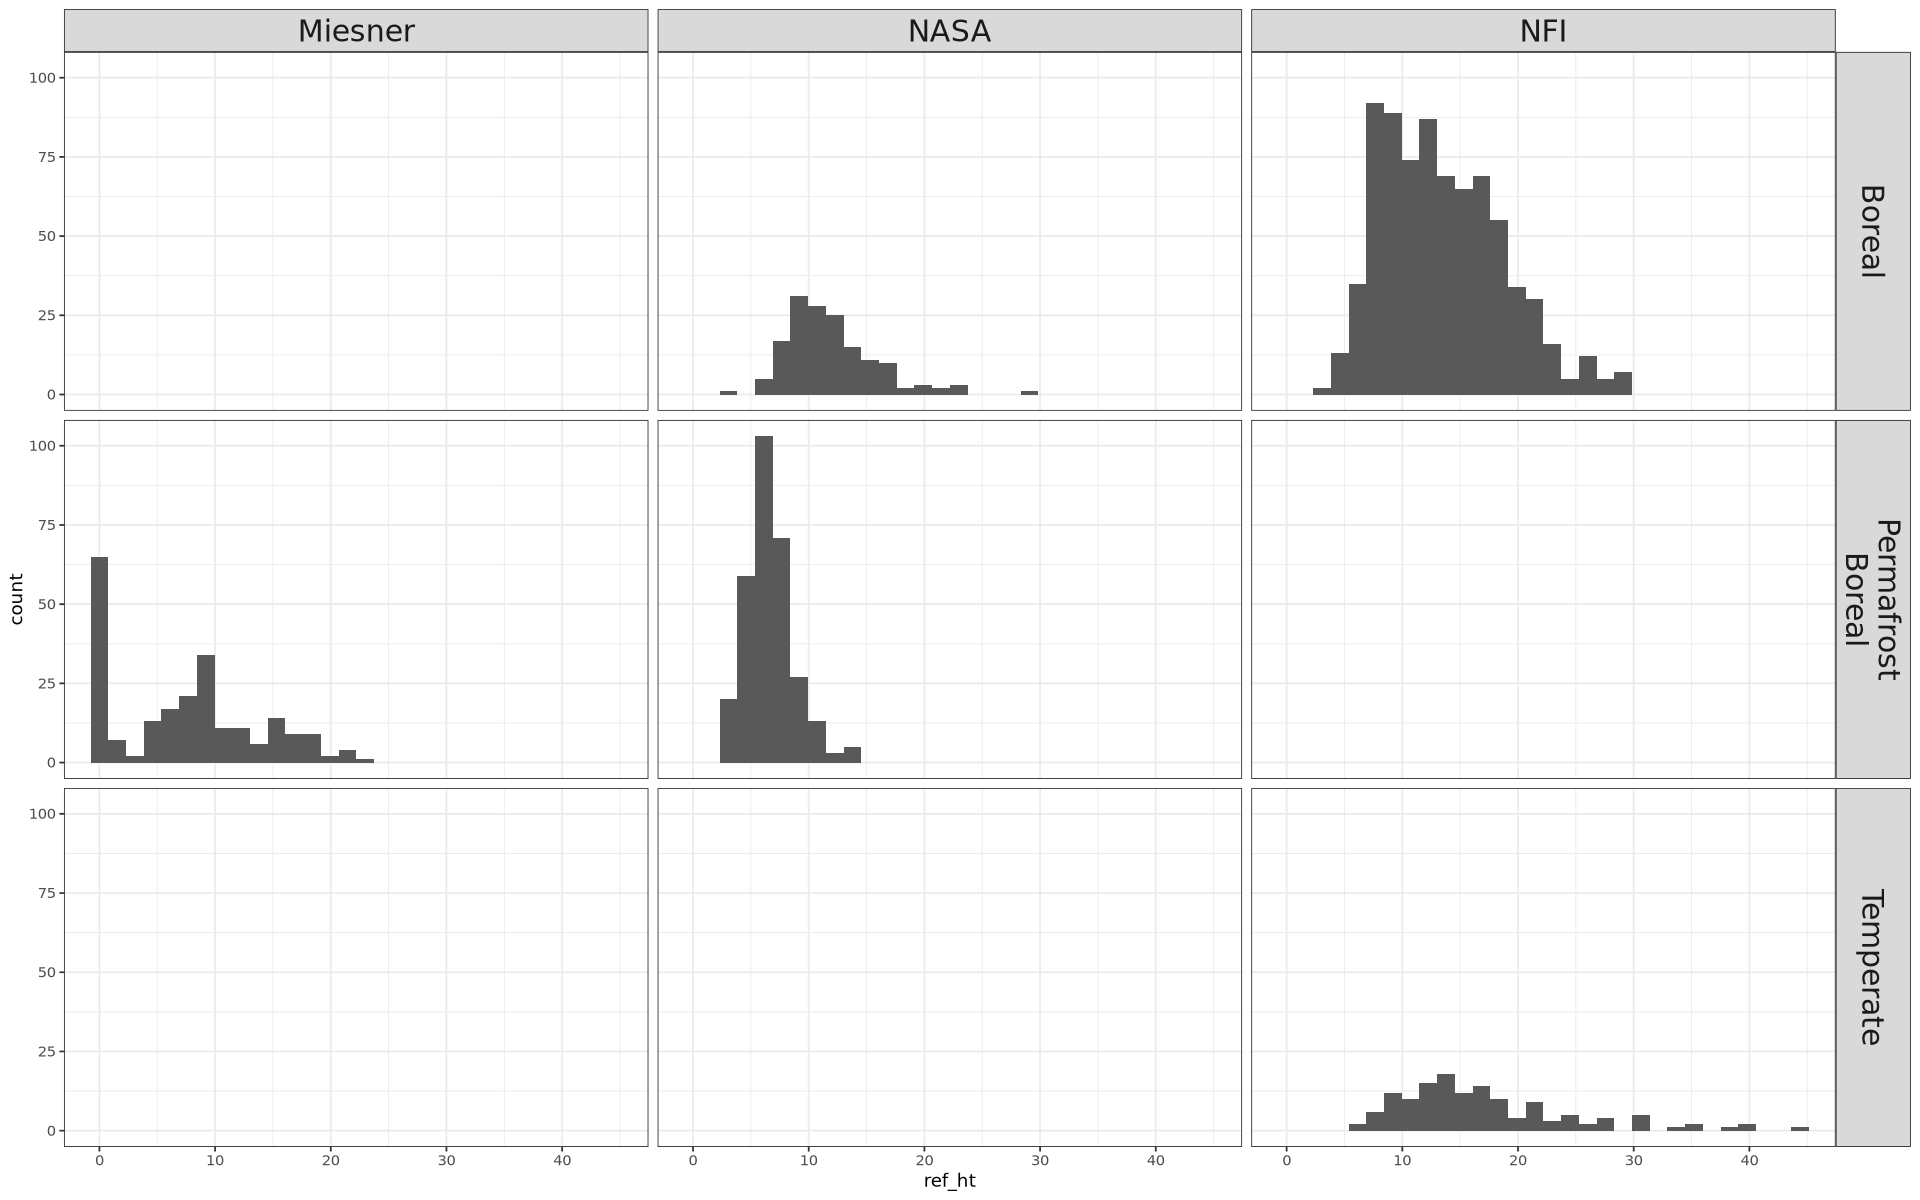

In [138]:
options(repr.plot.width = 16, repr.plot.height = 10)

# Set regions
val_plots_df = val_plots_df %>% 
                mutate(region = case_match(
                                    continent, c('Eurasia') ~ 'Permafrost\nBoreal',
                                               c('North America') ~ 'Boreal'

                ) ) %>%
                mutate(region = case_match( 
                                    group_name, 
                                        c('West Siberian Plains', 'Bahkta River','Tunguska River','Tahe','Russian Far East') ~ 'Boreal', 
                                       # (continent == 'North America' ~ 'Boreal') & (group_name != 'Atlantic Maritime' & group_name != 'Pacific Maritime' & group_name != 'Mixedwood Plains') ~ 'Boreal',
                                        c('Atlantic Maritime','Pacific Maritime','Mixedwood Plains') ~ 'Temperate',
                                    .default = region               
                                  )
                       ) %>%
                rowid_to_column("IDX")

#dim(val_plots_df %>% filter(continent != 'North America'))
#tail(val_plots_df %>% as.data.frame())
#ggplot() + geom_sf(data=ne_countries(scale = 10, returnclass = 'sf')) + geom_sf(data=val_plots_df, aes(color=region), size=1, alpha=0.25) + coord_sf(ylim=c(43.5,72.5))
ggplot() + geom_histogram(data=val_plots_df, aes(x=ref_ht
                                                 #, fill=factor(value_esawc2020)
                                                )) + 
facet_grid(region ~ source) + 
theme_bw() +
theme(strip.text = element_text(size=18)) #+
#scale_fill_manual(values = cols_worldcover, breaks = values_worldcover, labels = names_worldcover)
#scale_fill_viridis_d(option=6)

In [139]:
EXPORT_TIME_STR = format(Sys.time(), "%Y%m%d")
st_write(obj = val_plots_df, dsn = path(path_extracted, paste0('boreal_height_val_plots_cleaned_',DESC,'_',EXPORT_TIME_STR,'.gpkg')))

Writing layer `boreal_height_val_plots_cleaned_multiyr_v3.1__20260427' to data source 
  `/projects/my-public-bucket/databank/extract_from_points/boreal_height_val_plots_cleaned_multiyr_v3.1__20260427.gpkg' using driver `GPKG'
Writing 1578 features with 40 fields and geometry type Point.


In [140]:
dim(val_plots_df)

[1] 1578   41